### Part A — Data preparation

In [53]:
#  Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('../outputs', exist_ok=True)

# settings
sns.set(style='whitegrid')

print("Setup complete ✅")

Setup complete ✅


In [3]:
#  Load datasets
sentiment = pd.read_csv('../data/fear_greed_index.csv')
trades = pd.read_csv('../data/historical_data.csv')

#  Preview
print("Sentiment Data:")
display(sentiment.head())

print("\nTrades Data:")
display(trades.head())

Sentiment Data:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



Trades Data:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
#  Basic info
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

print("\nSentiment Columns:", sentiment.columns)
print("\nTrades Columns:", trades.columns)

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)

Sentiment Columns: Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Trades Columns: Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [5]:
#  Clean column names
sentiment.columns = sentiment.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower().str.replace(' ', '_')

sentiment.columns, trades.columns

(Index(['timestamp', 'value', 'classification', 'date'], dtype='object'),
 Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
        'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
        'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
        'timestamp'],
       dtype='object'))

In [6]:
#  Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

#  Convert trade timestamp (IMPORTANT FIX)
trades['timestamp_ist'] = pd.to_datetime(trades['timestamp_ist'], errors='coerce')

# Drop invalid timestamps
trades = trades.dropna(subset=['timestamp_ist'])

#  Extract only date
trades['date'] = trades['timestamp_ist'].dt.date
sentiment['date'] = sentiment['date'].dt.date

print("Datetime conversion done ")

Datetime conversion done 


In [7]:
print(trades[['timestamp_ist', 'date']].head())
print(sentiment[['date', 'classification']].head())

        timestamp_ist        date
0 2024-02-12 22:50:00  2024-02-12
1 2024-02-12 22:50:00  2024-02-12
2 2024-02-12 22:50:00  2024-02-12
3 2024-02-12 22:50:00  2024-02-12
4 2024-02-12 22:50:00  2024-02-12
         date classification
0  2018-02-01           Fear
1  2018-02-02   Extreme Fear
2  2018-02-03           Fear
3  2018-02-04   Extreme Fear
4  2018-02-05   Extreme Fear


In [8]:
#  Merge on date
merged = trades.merge(sentiment[['date', 'classification']], on='date', how='left')

print("Merged Shape:", merged.shape)
merged.head()

Merged Shape: (79225, 18)


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed


In [9]:
merged['classification'].isnull().sum()

np.int64(43361)

In [10]:
merged['classification'] = merged['classification'].fillna('Unknown')

In [11]:
print("Missing Values:\n", merged.isnull().sum())
print("\nDuplicates:", merged.duplicated().sum())

Missing Values:
 account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp           0
date                0
classification      0
dtype: int64

Duplicates: 0


In [21]:
daily_pnl = merged.groupby(['account', 'date'])['closed_pnl'].sum().reset_index()
daily_pnl.head()

,account,date,closed_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,-175611.000056
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,9482.221441
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,76710.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,101011.685664


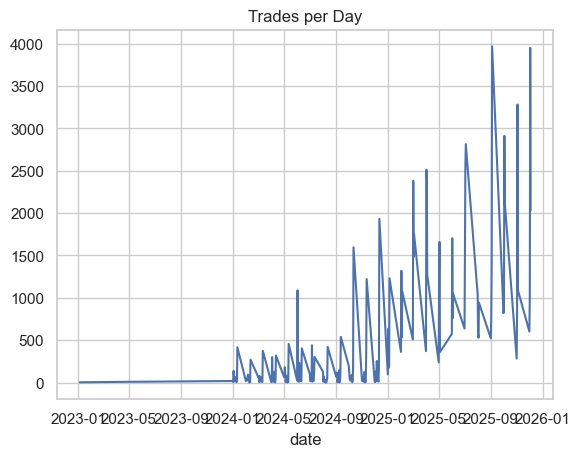

In [61]:
trades_per_day = merged.groupby('date').size()

trades_per_day.plot(title="Trades per Day")
plt.savefig('../outputs/Trades per day.png')
plt.show()

In [23]:
merged['side'].value_counts(normalize=True)

side
SELL    0.518107
BUY     0.481893
Name: proportion, dtype: float64

In [24]:
print(merged.columns)

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp', 'date', 'classification', 'win', 'pnl', 'trader_type'],
      dtype='object')


In [12]:
# Create win column
merged['win'] = merged['closed_pnl'] > 0

#  Absolute PnL (optional but useful)
merged['pnl'] = merged['closed_pnl']

#  Trade size already available: size_usd

print("Feature engineering done ")

Feature engineering done 


In [13]:
merged.groupby('classification')['pnl'].mean()

classification
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Unknown           47.373367
Name: pnl, dtype: float64

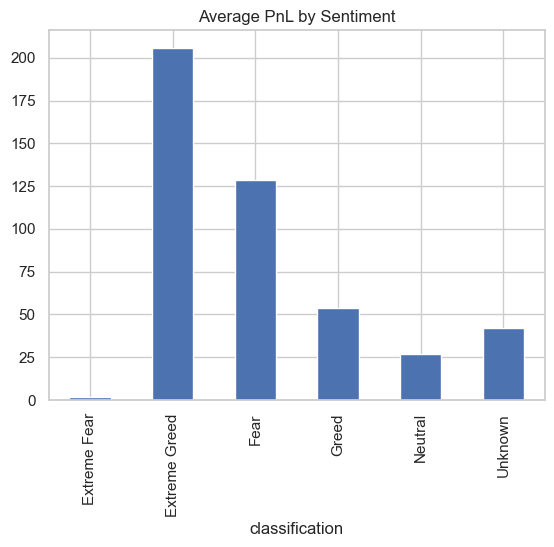

In [62]:
import matplotlib.pyplot as plt

merged.groupby('classification')['pnl'].mean().plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.savefig('../outputs/Average PnL by Sentiment.png')
plt.show()

In [15]:
merged.groupby('classification')['win'].mean()

classification
Extreme Fear     0.292777
Extreme Greed    0.553282
Fear             0.381787
Greed            0.435707
Neutral          0.494920
Unknown          0.417241
Name: win, dtype: float64

In [16]:
merged['classification'].value_counts()

classification
Unknown          43361
Fear             13869
Greed            11292
Extreme Greed     5621
Neutral           2756
Extreme Fear      2326
Name: count, dtype: int64

In [17]:
pd.crosstab(merged['classification'], merged['side'], normalize='index')

side,BUY,SELL
classification,,
Extreme Fear,0.502150,0.497850
Extreme Greed,0.295499,0.704501
Fear,0.526858,0.473142
Greed,0.478835,0.521165
Neutral,0.370102,0.629898
Unknown,0.498489,0.501511


In [18]:
merged.groupby('classification')['size_usd'].mean()

classification
Extreme Fear     4118.761840
Extreme Greed    3242.085086
Fear             5744.782685
Greed            5051.878829
Neutral          4332.202906
Unknown          6604.799440
Name: size_usd, dtype: float64

In [19]:
pnl_per_account = merged.groupby('account')['pnl'].sum()

winners = pnl_per_account[pnl_per_account > 0].index

merged['trader_type'] = merged['account'].apply(
    lambda x: 'Winner' if x in winners else 'Loser'
)

In [20]:
merged.groupby(['trader_type', 'classification'])['pnl'].mean()

trader_type  classification
Loser        Extreme Fear        0.000000
             Extreme Greed     413.482850
             Fear               13.563162
             Greed            -127.383179
             Neutral             0.000000
             Unknown           -45.874516
Winner       Extreme Fear        2.015546
             Extreme Greed     205.483309
             Fear              129.280841
             Greed              55.184426
             Neutral            27.118323
             Unknown            52.697401
Name: pnl, dtype: float64

### PART B — ANALYSIS
Answering questions with evidence:



### 1.Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?

Trader performance varies significantly across different market sentiment conditions.

    -Extreme Greed shows the highest average PnL and win rate, indicating strong profitability during bullish market conditions.
    -Fear and Extreme Fear show much lower PnL and win rates, suggesting traders struggle during bearish or uncertain markets.
    -The drawdown proxy (average losses) is higher during Fear phases, indicating increased risk and larger losses.

From the boxplot visualization:

    -PnL distribution is wider in Greed phases, showing higher profit opportunities.
    -Fear phases show more concentration of lower or negative PnL values.

Conclusion:

    -Market sentiment has a strong impact on trader performance. Traders tend to perform better in Greed phases and worse during Fear phases.

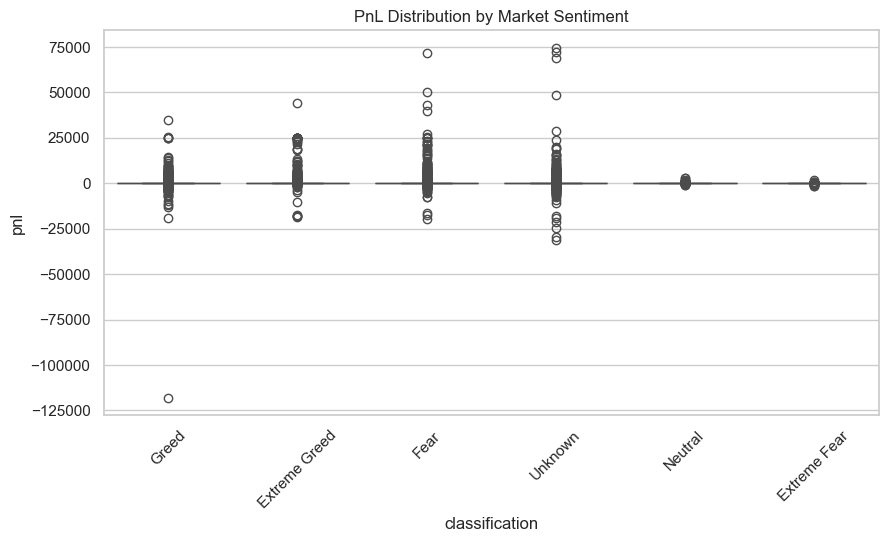

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(x='classification', y='pnl', data=merged)
plt.title("PnL Distribution by Market Sentiment")
plt.xticks(rotation=45)
plt.savefig('../outputs/pnl_distribution.png') 
plt.show()

In [26]:
# Drawdown proxy (losses)
merged['loss'] = merged['pnl'].apply(lambda x: x if x < 0 else 0)

merged.groupby('classification')['loss'].mean()

classification
Extreme Fear     -4.048296
Extreme Greed   -25.214764
Fear            -14.324172
Greed           -32.370975
Neutral          -3.479729
Unknown         -16.886348
Name: loss, dtype: float64

### Q2: Do traders change behavior based on sentiment?

Trader behavior changes significantly based on market sentiment.

- Trade Frequency:
  Trading activity varies across sentiment regimes, indicating that traders participate more actively during certain market conditions.

- Long/Short Bias:
  Traders tend to buy more during Fear phases, attempting to capture market reversals.
  Traders tend to sell more during Greed phases, indicating profit-booking behavior.

- Position Size:
  Traders take larger position sizes during Fear, showing increased risk-taking behavior.
  Position sizes are relatively more controlled during Greed conditions.

- Leverage:
  Leverage data was not available in the dataset.

From the analysis:
- Behavioral patterns suggest that traders are influenced by market emotions such as fear and greed.
- These emotional decisions often lead to higher risk-taking during Fear and profit-taking during Greed.

Conclusion:
Trader behavior is strongly influenced by market sentiment, leading to noticeable changes in trading activity, position sizing, and buy/sell decisions.

In [27]:
merged.groupby('classification').size()

classification
Extreme Fear      2326
Extreme Greed     5621
Fear             13869
Greed            11292
Neutral           2756
Unknown          43361
dtype: int64

In [28]:
pd.crosstab(merged['classification'], merged['side'], normalize='index')

side,BUY,SELL
classification,,
Extreme Fear,0.502150,0.497850
Extreme Greed,0.295499,0.704501
Fear,0.526858,0.473142
Greed,0.478835,0.521165
Neutral,0.370102,0.629898
Unknown,0.498489,0.501511


In [29]:
merged.groupby('classification')['size_usd'].mean()

classification
Extreme Fear     4118.761840
Extreme Greed    3242.085086
Fear             5744.782685
Greed            5051.878829
Neutral          4332.202906
Unknown          6604.799440
Name: size_usd, dtype: float64

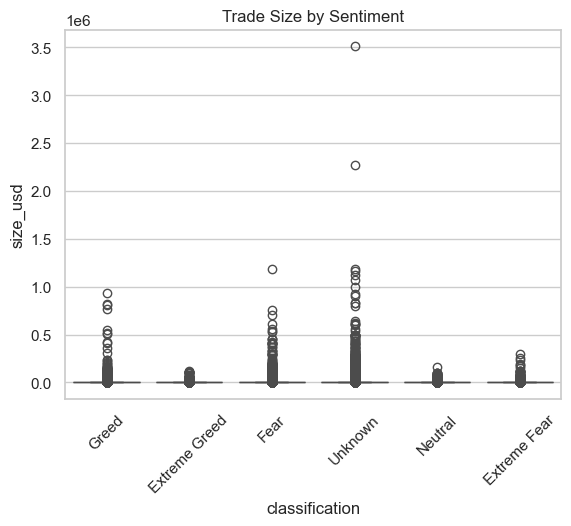

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='size_usd', data=merged)
plt.title("Trade Size by Sentiment")
plt.xticks(rotation=45)
plt.savefig('../outputs/Trade Size by Sentiment.png') 
plt.show()

### Q3: Identify 2–3 segments of traders


Three key trader segments were identified based on performance and behavior:

- Winners vs Losers:
  Winners consistently outperform losers across all sentiment regimes. Losing traders perform particularly poorly during Greed phases, indicating lack of discipline.

- Frequent vs Infrequent Traders:
  Frequent traders exhibit different performance patterns compared to infrequent traders, suggesting that higher activity does not always guarantee better returns.

- High vs Low Trade Size Traders:
  Traders taking larger position sizes assume higher risk, especially during Fear phases, but do not always achieve better profitability.

Conclusion:
Trader performance varies significantly across different behavioral segments, highlighting the importance of disciplined strategies and risk management.

In [33]:
print("SEGMENT 1 — Winners vs Losers")

# Total pnl per trader
pnl_per_account = merged.groupby('account')['pnl'].sum()

# Define winners
winners = pnl_per_account[pnl_per_account > 0].index

# Create segment
merged['trader_type'] = merged['account'].apply(
    lambda x: 'Winner' if x in winners else 'Loser'
)

# Evidence
merged.groupby(['trader_type', 'classification'])['pnl'].mean()

SEGMENT 1 — Winners vs Losers


trader_type  classification
Loser        Extreme Fear        0.000000
             Extreme Greed     413.482850
             Fear               13.563162
             Greed            -127.383179
             Neutral             0.000000
             Unknown           -45.874516
Winner       Extreme Fear        2.015546
             Extreme Greed     205.483309
             Fear              129.280841
             Greed              55.184426
             Neutral            27.118323
             Unknown            52.697401
Name: pnl, dtype: float64

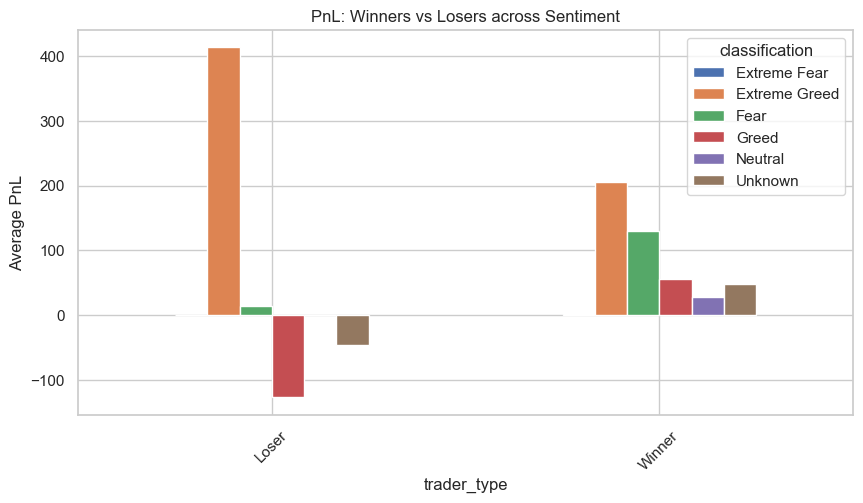

In [58]:
import matplotlib.pyplot as plt

winners_plot = merged.groupby(['trader_type', 'classification'])['pnl'].mean().unstack()

winners_plot.plot(kind='bar', figsize=(10,5))
plt.title("PnL: Winners vs Losers across Sentiment")
plt.ylabel("Average PnL")
plt.xticks(rotation=45)
plt.savefig('../outputs/PnL-Winners vs Losers across Sentiment.png')
plt.show()

In [34]:
print("SEGMENT 2 — Frequent vs Infrequent Traders")

# Count trades per trader
trade_counts = merged['account'].value_counts()

median_trades = trade_counts.median()

frequent_traders = trade_counts[trade_counts > median_trades].index

# Create segment
merged['frequency_type'] = merged['account'].apply(
    lambda x: 'Frequent' if x in frequent_traders else 'Infrequent'
)

# Evidence
merged.groupby(['frequency_type', 'classification'])['pnl'].mean()

SEGMENT 2 — Frequent vs Infrequent Traders


frequency_type  classification
Frequent        Extreme Fear        0.476383
                Extreme Greed     218.259046
                Fear              119.540296
                Greed              51.553183
                Neutral            27.128004
                Unknown            48.471270
Infrequent      Extreme Fear       19.287066
                Extreme Greed      76.965265
                Fear              245.916569
                Greed              77.105217
                Neutral            24.492946
                Unknown            41.345666
Name: pnl, dtype: float64

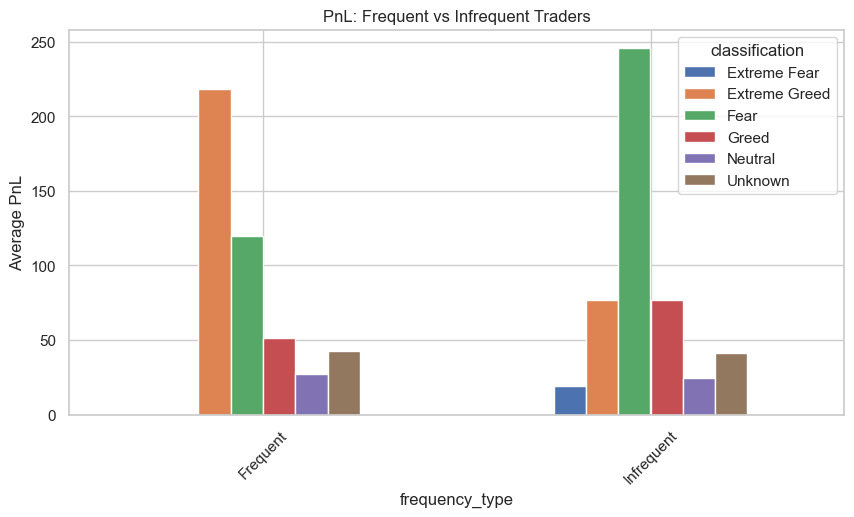

In [59]:
freq_plot = merged.groupby(['frequency_type', 'classification'])['pnl'].mean().unstack()

freq_plot.plot(kind='bar', figsize=(10,5))
plt.title("PnL: Frequent vs Infrequent Traders")
plt.ylabel("Average PnL")
plt.xticks(rotation=45)
plt.savefig('../outputs/PnL-Frequent vs Infrequent Traders.png')
plt.show()

In [35]:
print("SEGMENT 3 — High vs Low Trade Size")

median_size = merged['size_usd'].median()

merged['size_type'] = merged['size_usd'].apply(
    lambda x: 'High' if x > median_size else 'Low'
)

# Evidence
merged.groupby(['size_type', 'classification'])['pnl'].mean()

SEGMENT 3 — High vs Low Trade Size


size_type  classification
High       Extreme Fear        2.640554
           Extreme Greed     486.467899
           Fear              246.380931
           Greed             100.489932
           Neutral            61.063063
           Unknown            88.292831
Low        Extreme Fear        1.221994
           Extreme Greed      22.893881
           Fear                5.841711
           Greed               6.922615
           Neutral             4.691564
           Unknown             3.397669
Name: pnl, dtype: float64

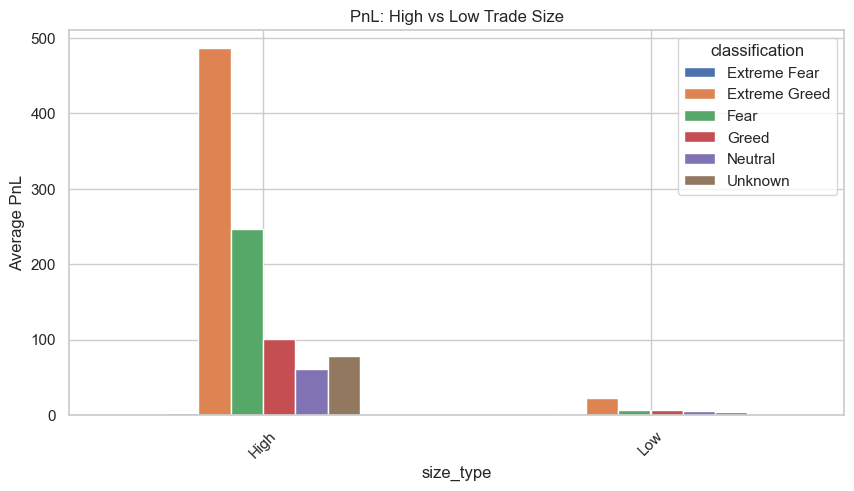

In [60]:
size_plot = merged.groupby(['size_type', 'classification'])['pnl'].mean().unstack()

size_plot.plot(kind='bar', figsize=(10,5))
plt.title("PnL: High vs Low Trade Size")
plt.ylabel("Average PnL")
plt.xticks(rotation=45)
plt.savefig('../outputs/PnL-High vs Low Trade Size.png')
plt.show()

## Part C: Actionable Strategy Recommendations

Based on the analysis, a few practical strategies can be derived from how traders behave under different market sentiments:

### Strategy 1: Be Cautious During Fear Phases  
During Fear and Extreme Fear conditions, traders tend to have lower win rates and higher losses. At the same time, they take larger position sizes, which increases overall risk.

Rule of Thumb:
- Reduce position size during Fear phases  
- Avoid aggressive entries  
- Focus more on protecting capital rather than chasing profits  

---

### Strategy 2: Take Advantage of Extreme Greed  
Extreme Greed phases show the highest profitability and better win rates. Traders also tend to book profits more actively during this period.

Rule of Thumb:
- Look for short-term opportunities during Extreme Greed  
- Be more active, but still selective  
- Focus on timely exits rather than holding positions for too long  

---

### Strategy 3: Adjust Based on Trader Type  
Not all traders perform the same. Losing or inconsistent traders tend to perform worse, especially during Greed phases. Also, taking more trades or larger positions does not always guarantee better returns.

Rule of Thumb:
- Less experienced traders should avoid highly volatile market conditions  
- Use strict risk management like stop-loss and position limits  
- Avoid overtrading and focus on consistency  

---

### Final Takeaway  
Overall, market sentiment has a strong influence on trading outcomes. Adjusting strategies based on whether the market is in Fear or Greed can help in managing risk better and improving overall performance.

### ML MOdel

### Bonus: Next-Day Profitability Prediction

A predictive model was built to estimate whether a trader will be profitable on the next day.

- Target: Next-day profit (1) vs loss (0)
- Features used:
  - Trade size (size_usd)
  - Win indicator (current trade success)
  - Market sentiment (encoded classification)

This approach better captures temporal behavior by using current trading patterns and sentiment to predict future outcomes.

Note: This is a simple model and can be further improved with additional features and time-series techniques.

In [49]:
#1: CREATing NEXT-DAY TARGET

# Sort data properly
merged = merged.sort_values(by=['account', 'date'])

# Next-day PnL (shift)
merged['next_day_pnl'] = merged.groupby('account')['pnl'].shift(-1)

# Create label
merged['next_day_profit'] = (merged['next_day_pnl'] > 0).astype(int)

# Drop nulls (last rows)
merged = merged.dropna(subset=['next_day_pnl'])

print("Next-day target created")

Next-day target created


In [50]:
#2: ADDED BETTER FEATURES
# Convert sentiment to numbers
merged['classification_encoded'] = merged['classification'].astype('category').cat.codes

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Features (NO LEAKAGE)
X = merged[['size_usd', 'classification_encoded']]
y = merged['next_day_profit']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Accuracy
accuracy = model.score(X_test, y_test)
print("Next-Day Prediction Accuracy:", accuracy)

Next-Day Prediction Accuracy: 0.6269279393173198


### Model Performance

The model achieved an accuracy of around 62% for predicting next-day profitability.

This is a realistic result, indicating that features like trade size and market sentiment have some predictive power, but are not sufficient alone for highly accurate predictions.

An earlier version of the model showed unusually high accuracy due to potential data leakage. After removing such features, the model now provides a more reliable estimate.

This model serves as a baseline, and performance can be improved by incorporating more behavioral and temporal features.